---
## 0 · Environment Setup

This notebook provides a full end-to-end workflow for analysing the IDSSE dataset:

1. **Task 1** — Download, validate, and parse XML files into analysis-ready DataFrames.
2. **Task 2** — Visualise events, tracking, and possession data.
3. **Task 3** — Quantify and decompose Net Playing Time (NPT).

> Run all cells sequentially from top to bottom for reproducibility.

In [2]:
import os
import sys
import warnings
from pathlib import Path

# Resolve project root (works across machines and launch paths)
ROOT = Path.cwd().resolve()
if not (ROOT / "src").exists():
    for parent in [ROOT, *ROOT.parents]:
        if (parent / "src").exists():
            ROOT = parent
            break

os.chdir(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

warnings.filterwarnings("ignore")

# Common imports
import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})

# Data directory
DATA_DIR = ROOT / ".data"
DATA_DIR.mkdir(exist_ok=True)

print("Project root :", ROOT)
print("Data directory:", DATA_DIR)

Project root : /Users/sunjaekweon/idsse_npt
Data directory: /Users/sunjaekweon/idsse_npt/.data


---
## Task 1 · Access, Download, and Parse

### 1.1 · Dataset Overview

The IDSSE release provides **three XML files per match**:

| File type | Content | Typical size |
|---|---|---|
| `matchinformation` | Match metadata (teams, players, venue, timing fields) | ~12 KB |
| `events_raw` | Event annotations (passes, shots, fouls, …) | ~800 KB |
| `positions_raw_observed` | 25 Hz tracking (players + ball) | ~400 MB |

Seven matches are included:
`J03WMX`, `J03WN1`, `J03WPY`, `J03WOH`, `J03WQQ`, `J03WOY`, `J03WR9`.

### 1.2 · Download and Validation

Data is fetched from **Figshare article `28196177`**.
`src/download.py` handles:
- Fetching file metadata (`download_url`, `computed_md5`) from the Figshare API.
- Streaming files to `DATA_DIR / "idsse_dataset"`.
- Integrity validation via MD5 checksum.
- Skipping already-valid files on re-run.

In [3]:
from src.download import download_all_matches, validate_downloads, MATCH_IDS

# Skip download if all files already exist locally; otherwise download
if validate_downloads(DATA_DIR, check_md5=False):
    print("Local IDSSE files already available — skipping download.")
    results = {}
else:
    print("Local files incomplete — starting download ...")
    results = download_all_matches(DATA_DIR, skip_existing=True)

Validating files (md5_check=False) ...
  ✅  DFL_02_01_matchinformation_DFL-COM-000001_DFL-MAT-J03WMX.xml  (0.0 MB)
  ✅  DFL_03_02_events_raw_DFL-COM-000001_DFL-MAT-J03WMX.xml  (0.7 MB)
  ✅  DFL_04_03_positions_raw_observed_DFL-COM-000001_DFL-MAT-J03WMX.xml  (399.1 MB)
  ✅  DFL_02_01_matchinformation_DFL-COM-000001_DFL-MAT-J03WN1.xml  (0.0 MB)
  ✅  DFL_03_02_events_raw_DFL-COM-000001_DFL-MAT-J03WN1.xml  (0.6 MB)
  ✅  DFL_04_03_positions_raw_observed_DFL-COM-000001_DFL-MAT-J03WN1.xml  (373.6 MB)
  ✅  DFL_02_01_matchinformation_DFL-COM-000002_DFL-MAT-J03WPY.xml  (0.0 MB)
  ✅  DFL_03_02_events_raw_DFL-COM-000002_DFL-MAT-J03WPY.xml  (0.7 MB)
  ✅  DFL_04_03_positions_raw_observed_DFL-COM-000002_DFL-MAT-J03WPY.xml  (354.5 MB)
  ✅  DFL_02_01_matchinformation_DFL-COM-000002_DFL-MAT-J03WOH.xml  (0.0 MB)
  ✅  DFL_03_02_events_raw_DFL-COM-000002_DFL-MAT-J03WOH.xml  (0.6 MB)
  ✅  DFL_04_03_positions_raw_observed_DFL-COM-000002_DFL-MAT-J03WOH.xml  (332.8 MB)
  ✅  DFL_02_01_matchinformation_DFL-COM-0

In [4]:
# Validate integrity of downloaded files
all_ok = validate_downloads(DATA_DIR)
print(f"All files valid: {all_ok}")

Validating files (md5_check=False) ...
  ✅  DFL_02_01_matchinformation_DFL-COM-000001_DFL-MAT-J03WMX.xml  (0.0 MB)
  ✅  DFL_03_02_events_raw_DFL-COM-000001_DFL-MAT-J03WMX.xml  (0.7 MB)
  ✅  DFL_04_03_positions_raw_observed_DFL-COM-000001_DFL-MAT-J03WMX.xml  (399.1 MB)
  ✅  DFL_02_01_matchinformation_DFL-COM-000001_DFL-MAT-J03WN1.xml  (0.0 MB)
  ✅  DFL_03_02_events_raw_DFL-COM-000001_DFL-MAT-J03WN1.xml  (0.6 MB)
  ✅  DFL_04_03_positions_raw_observed_DFL-COM-000001_DFL-MAT-J03WN1.xml  (373.6 MB)
  ✅  DFL_02_01_matchinformation_DFL-COM-000002_DFL-MAT-J03WPY.xml  (0.0 MB)
  ✅  DFL_03_02_events_raw_DFL-COM-000002_DFL-MAT-J03WPY.xml  (0.7 MB)
  ✅  DFL_04_03_positions_raw_observed_DFL-COM-000002_DFL-MAT-J03WPY.xml  (354.5 MB)
  ✅  DFL_02_01_matchinformation_DFL-COM-000002_DFL-MAT-J03WOH.xml  (0.0 MB)
  ✅  DFL_03_02_events_raw_DFL-COM-000002_DFL-MAT-J03WOH.xml  (0.6 MB)
  ✅  DFL_04_03_positions_raw_observed_DFL-COM-000002_DFL-MAT-J03WOH.xml  (332.8 MB)
  ✅  DFL_02_01_matchinformation_DFL-COM-0

---
### 1.3 · Parsing Strategy

`src/parser.py` wraps **floodlight** and returns flat DataFrames.
Core tables used throughout this notebook:

| DataFrame | Source | Key columns |
|---|---|---|
| `events` | Event XML | `match_id`, `segment`, `team`, `eID`, `gameclock`, `at_x/y`, `to_x/y` |
| `codes` | Position XML | `match_id`, `segment`, `frame`, `gameclock_s`, `ballstatus`, `possession` |
| `teamsheets` | Matchinfo XML | `match_id`, `team`, player identifiers and metadata |

> Tracking data is loaded separately (`parse_tracking`, `parse_ball_tracking`) due to its large size.

In [5]:
from pathlib import Path
import pandas as pd
from src.download import MATCH_IDS
from src.parser import parse_match

# Parse all 7 matches (pickle cache for speed on re-run)
match_ids_to_parse = list(MATCH_IDS)
cache_dir = DATA_DIR / "cache_parsed"
cache_dir.mkdir(exist_ok=True)

all_data = {}
for mid in match_ids_to_parse:
    cache_path = cache_dir / f"{mid}_parsed.pkl"
    if cache_path.exists():
        all_data[mid] = pd.read_pickle(cache_path)
        print(f"Loaded cache: {mid} -> {cache_path.name}")
    else:
        parsed = parse_match(mid, DATA_DIR)
        pd.to_pickle(parsed, cache_path)
        all_data[mid] = parsed
        print(f"Parsed + cached: {mid} -> {cache_path.name}")

print(f"\nParsed matches: {len(all_data)}")

Loaded cache: J03WMX -> J03WMX_parsed.pkl
Loaded cache: J03WN1 -> J03WN1_parsed.pkl
Loaded cache: J03WPY -> J03WPY_parsed.pkl
Loaded cache: J03WOH -> J03WOH_parsed.pkl
Loaded cache: J03WQQ -> J03WQQ_parsed.pkl
Loaded cache: J03WOY -> J03WOY_parsed.pkl
Loaded cache: J03WR9 -> J03WR9_parsed.pkl

Parsed matches: 7


#### Event data overview

In [6]:
# Combine events across all matches
events_all = pd.concat([d["events"] for d in all_data.values()], ignore_index=True)

print(f"Total events: {len(events_all):,} rows across {events_all['match_id'].nunique()} matches")
print(f"Columns     : {list(events_all.columns)}\n")
events_all.head(10)

Total events: 10,498 rows across 7 matches
Columns     : ['match_id', 'segment', 'team', 'eID', 'gameclock', 'tID', 'pID', 'outcome', 'at_x', 'at_y', 'to_x', 'to_y', 'timestamp', 'minute', 'second', 'qualifier']



,match_id,segment,team,eID,gameclock,tID,pID,outcome,at_x,at_y,to_x,to_y,timestamp,minute,second,qualifier
0,J03WMX,firstHalf,Home,ThrowIn_Play_Pass,21.551,DFL-CLU-000008,DFL-OBJ-0002BO,NaN,79.65,68.00,79.65,68.00,2023-05-27 15:30:33.781000+02:00,0.0,21.0,"{'Team': 'DFL-CLU-000008', 'Side': 'right', 'D..."
1,J03WMX,firstHalf,Home,TacklingGame,22.268,DFL-CLU-000008,DFL-OBJ-J01BGM,1.0,NaN,NaN,50.55,59.11,2023-05-27 15:30:34.498000+02:00,0.0,22.0,"{'WinnerTeam': 'DFL-CLU-00000G', 'Winner': 'DF..."
2,J03WMX,firstHalf,Home,TacklingGame,25.216,DFL-CLU-000008,DFL-OBJ-0027AX,1.0,NaN,NaN,56.75,53.22,2023-05-27 15:30:37.446000+02:00,0.0,25.0,"{'WinnerTeam': 'DFL-CLU-00000G', 'Winner': 'DF..."
3,J03WMX,firstHalf,Home,OtherBallAction,44.291,DFL-CLU-000008,DFL-OBJ-0027B6,NaN,74.24,50.35,74.24,50.35,2023-05-27 15:30:56.521000+02:00,0.0,44.0,"{'Player': 'DFL-OBJ-0027B6', 'Team': 'DFL-CLU-..."
4,J03WMX,firstHalf,Home,Delete,68.364,None,None,NaN,NaN,NaN,NaN,NaN,2023-05-27 15:31:20.594000+02:00,1.0,8.0,{}
5,J03WMX,firstHalf,Home,OtherBallAction,83.800,DFL-CLU-000008,DFL-OBJ-J01D1W,NaN,56.01,3.21,56.01,3.21,2023-05-27 15:31:36.030000+02:00,1.0,23.0,"{'Player': 'DFL-OBJ-J01D1W', 'Team': 'DFL-CLU-..."
6,J03WMX,firstHalf,Home,BallClaiming,95.278,DFL-CLU-000008,DFL-OBJ-002GKO,NaN,NaN,NaN,48.69,52.86,2023-05-27 15:31:47.508000+02:00,1.0,35.0,"{'Player': 'DFL-OBJ-002GKO', 'Team': 'DFL-CLU-..."
7,J03WMX,firstHalf,Home,Play_Pass,95.279,DFL-CLU-000008,DFL-OBJ-002GKO,NaN,48.69,52.86,48.69,52.86,2023-05-27 15:31:47.509000+02:00,1.0,35.0,"{'SemiField': 'false', 'Player': 'DFL-OBJ-002G..."
8,J03WMX,firstHalf,Home,Play_Cross,99.010,DFL-CLU-000008,DFL-OBJ-J01BGM,NaN,11.72,64.39,11.72,64.39,2023-05-27 15:31:51.240000+02:00,1.0,39.0,"{'SemiField': 'false', 'Player': 'DFL-OBJ-J01B..."
9,J03WMX,firstHalf,Home,ShotAtGoal_ShotWide,102.336,DFL-CLU-000008,DFL-OBJ-0027AX,0.0,14.13,41.92,14.13,41.92,2023-05-27 15:31:54.566000+02:00,1.0,42.0,"{'Team': 'DFL-CLU-000008', 'Pressure': '0.68',..."


In [7]:
# Event counts per match × segment × team
events_all.groupby(["match_id", "segment", "team"]).size().unstack(["segment", "team"])

segment  firstHalf      secondHalf     
team          Away Home       Away Home
match_id                               
J03WMX         471  426        360  458
J03WN1         305  415        338  305
J03WOH         317  410        325  337
J03WOY         337  382        372  398
J03WPY         278  500        298  428
J03WQQ         412  422        433  319
J03WR9         313  438        254  447

In [8]:
# Top 15 event types across all matches
events_all["eID"].value_counts().rename("count").to_frame().head(15)

,count
eID,
Play_Pass,5241
OtherBallAction,1699
TacklingGame,1412
Delete,537
ThrowIn_Play_Pass,281
BallClaiming,206
Foul,160
FreeKick_Play_Pass,156
Play_Cross,140


#### Ball-status and possession codes

In [9]:
# Combine codes across all matches
codes_all = pd.concat([d["codes"] for d in all_data.values()], ignore_index=True)

# Per-match summary: total frames, alive frames, alive %, duration
summary = (
    codes_all.groupby("match_id")
    .agg(
        total_frames=("frame", "count"),
        alive_frames=("ballstatus", lambda s: int((s == 1).sum())),
        duration_min=("gameclock_s", "max"),
    )
    .assign(
        alive_pct=lambda df: (df["alive_frames"] / df["total_frames"] * 100).round(1),
        duration_min=lambda df: (df["duration_min"] / 60).round(1),
    )
)
summary

,total_frames,alive_frames,duration_min,alive_pct
match_id,,,,
J03WMX,145967,85369,50.2,58.5
J03WN1,141561,68377,48.2,48.3
J03WOH,137214,71945,46.3,52.4
J03WOY,142536,76286,48.9,53.5
J03WPY,146211,81460,51.4,55.7
J03WQQ,142345,84352,48.8,59.3
J03WR9,146810,85316,52.3,58.1


#### Teamsheets

In [10]:
# Combine teamsheets across all matches
teamsheets_all = pd.concat([d["teamsheets"] for d in all_data.values()], ignore_index=True)

print(f"Total rows: {len(teamsheets_all)}  ({teamsheets_all['match_id'].nunique()} matches × 2 teams)")
teamsheets_all.head(10)

Total rows: 279  (7 matches × 2 teams)


,match_id,player,position,team,jID,pID,tID,xID
0,J03WMX,F. Kainz,ZO,1. FC Köln,11,DFL-OBJ-0027AX,DFL-CLU-000008,0
1,J03WMX,Timo Horn,None,1. FC Köln,1,DFL-OBJ-0000M0,DFL-CLU-000008,1
2,J03WMX,Jonas Hector,LV,1. FC Köln,14,DFL-OBJ-00012X,DFL-CLU-000008,2
3,J03WMX,D. Selke,STZ,1. FC Köln,27,DFL-OBJ-000270,DFL-CLU-000008,3
4,J03WMX,M. Schwäbe,TW,1. FC Köln,20,DFL-OBJ-0002HE,DFL-CLU-000008,4
5,J03WMX,B. Schmitz,RV,1. FC Köln,2,DFL-OBJ-0002BO,DFL-CLU-000008,5
6,J03WMX,K. Schindler,RV,1. FC Köln,17,DFL-OBJ-0027V2,DFL-CLU-000008,6
7,J03WMX,Timo Hübers,IVR,1. FC Köln,4,DFL-OBJ-0027B6,DFL-CLU-000008,7
8,J03WMX,Kristian Pedersen,LV,1. FC Köln,3,DFL-OBJ-0026ZI,DFL-CLU-000008,8
9,J03WMX,L. Maina,OLM,1. FC Köln,37,DFL-OBJ-0028BD,DFL-CLU-000008,9


---
## Task 2 · Visualisation

`src/visualization.py` provides the following plotting functions:

| Category | Function | Purpose |
|---|---|---|
| Event | `plot_pass_map()` | Pass directions coloured by outcome |
| Event | `plot_shot_chart()` | Shot locations with xG-scaled markers |
| Tracking | `plot_heatmap()` | 2D positional density on pitch |
| Possession | `plot_possession_timeline()` | Per-minute possession momentum chart |
| NPT | `plot_restart_map()` | Restart locations + dead-ball breakdown |

> First-half coordinates are automatically mirrored so that **Home always attacks left → right**.

In [11]:
from src.parser import parse_team_names
from src.visualization import (
    draw_pitch, plot_pass_map, plot_shot_chart,
    plot_heatmap, plot_possession_timeline, plot_restart_map,
)

# Build team-name lookup for all matches
team_names_all = {mid: parse_team_names(mid, DATA_DIR) for mid in MATCH_IDS}
tn_J03WMX = team_names_all["J03WMX"]
print("J03WMX teams:", tn_J03WMX)

J03WMX teams: {'Away': 'FC Bayern München', 'Home': '1. FC Köln'}


### 2.1 · Pass Map

Pass and cross events for **J03WMX** (1. FC Köln vs FC Bayern München), split by team.
Green = successful, Red = unsuccessful.

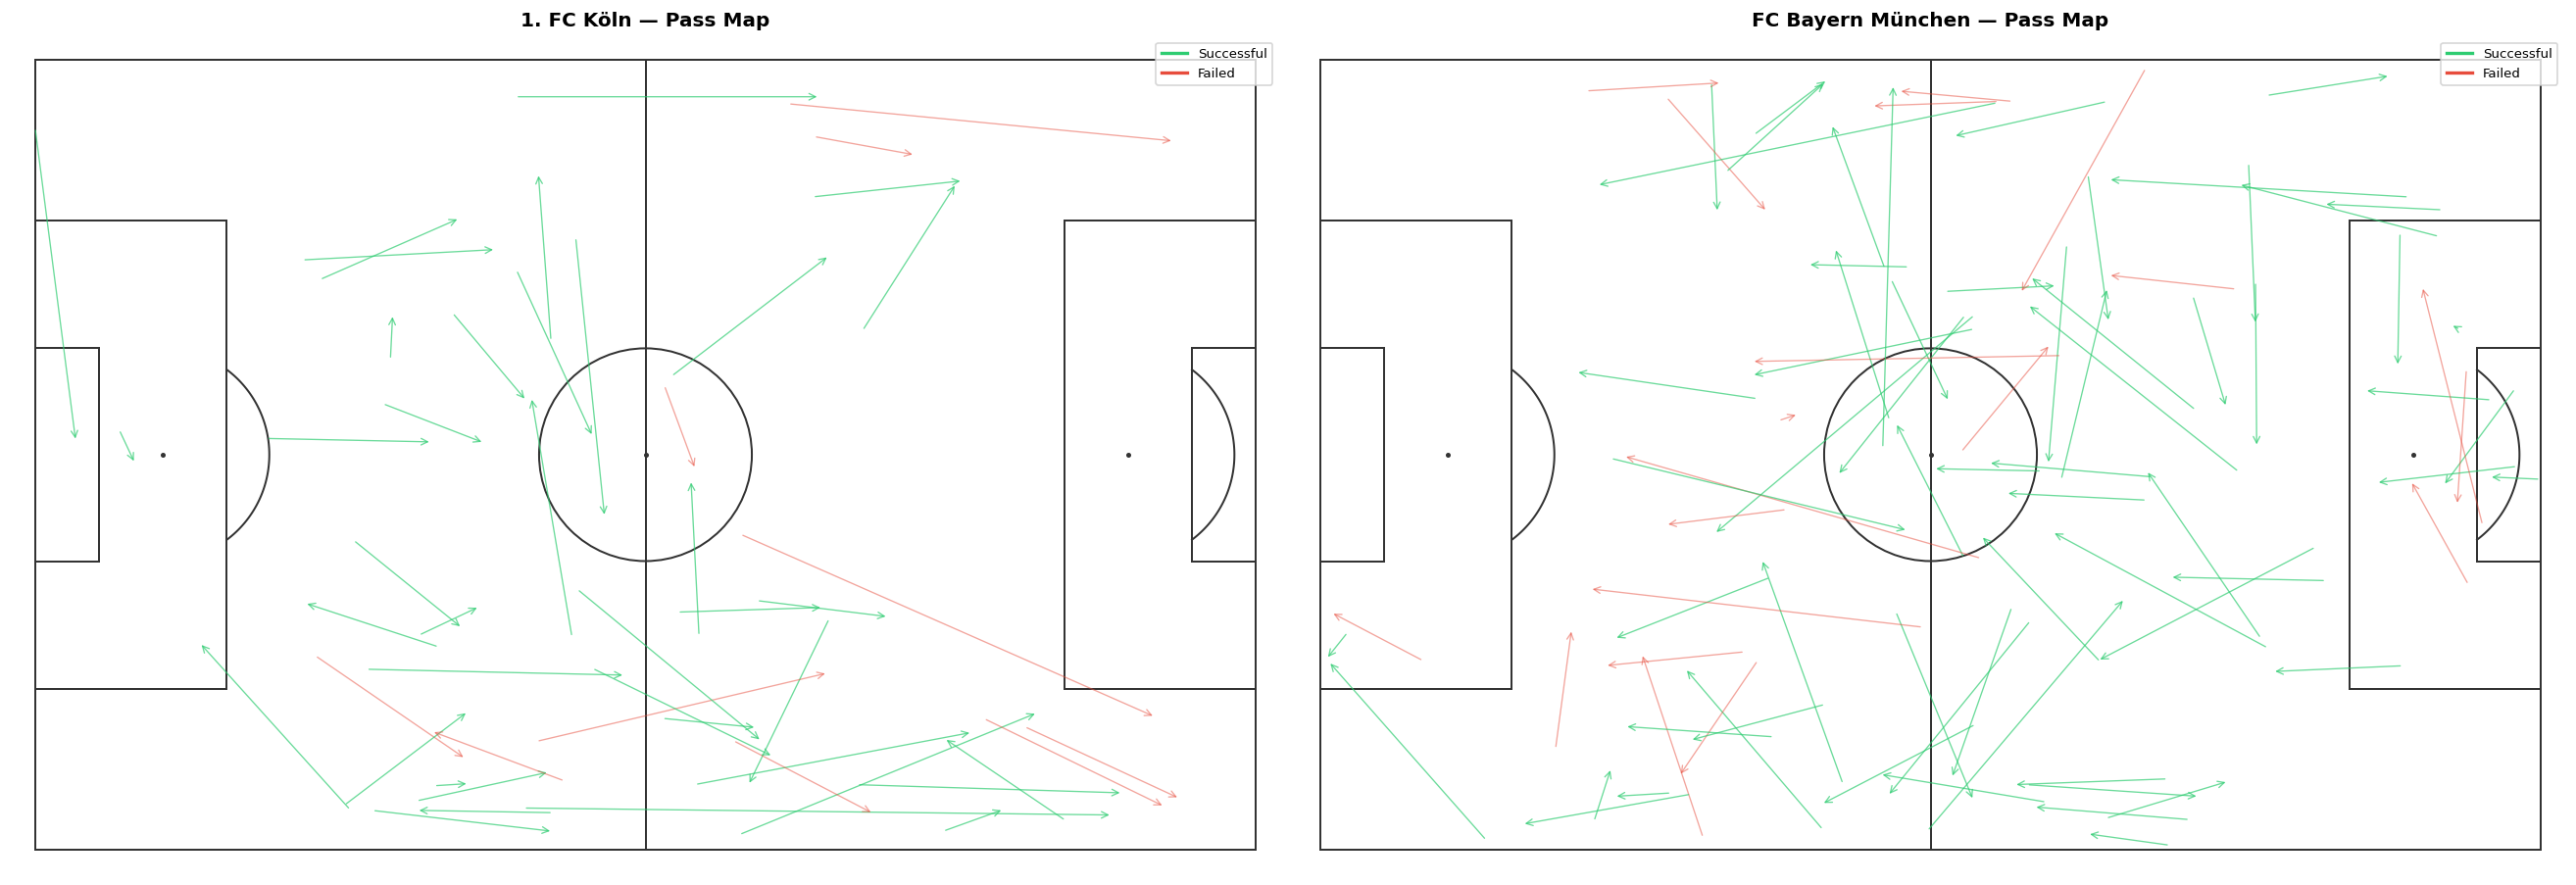

In [12]:
events_J03WMX = events_all[events_all["match_id"] == "J03WMX"]
home_name = tn_J03WMX["Home"]
away_name = tn_J03WMX["Away"]

# Side-by-side pass maps for Home and Away
fig, axes = plt.subplots(1, 2, figsize=(22, 8))
plot_pass_map(events_J03WMX, team="Home", ax=axes[0],
              title=f"{home_name} — Pass Map", team_names=tn_J03WMX)
plot_pass_map(events_J03WMX, team="Away", ax=axes[1],
              title=f"{away_name} — Pass Map", team_names=tn_J03WMX)
plt.tight_layout()
plt.show()

### 2.2 · Shot Chart (xG)

All shots for **J03WMX** on a full pitch.
Marker area scales with xG; circles = non-goals, stars = goals.

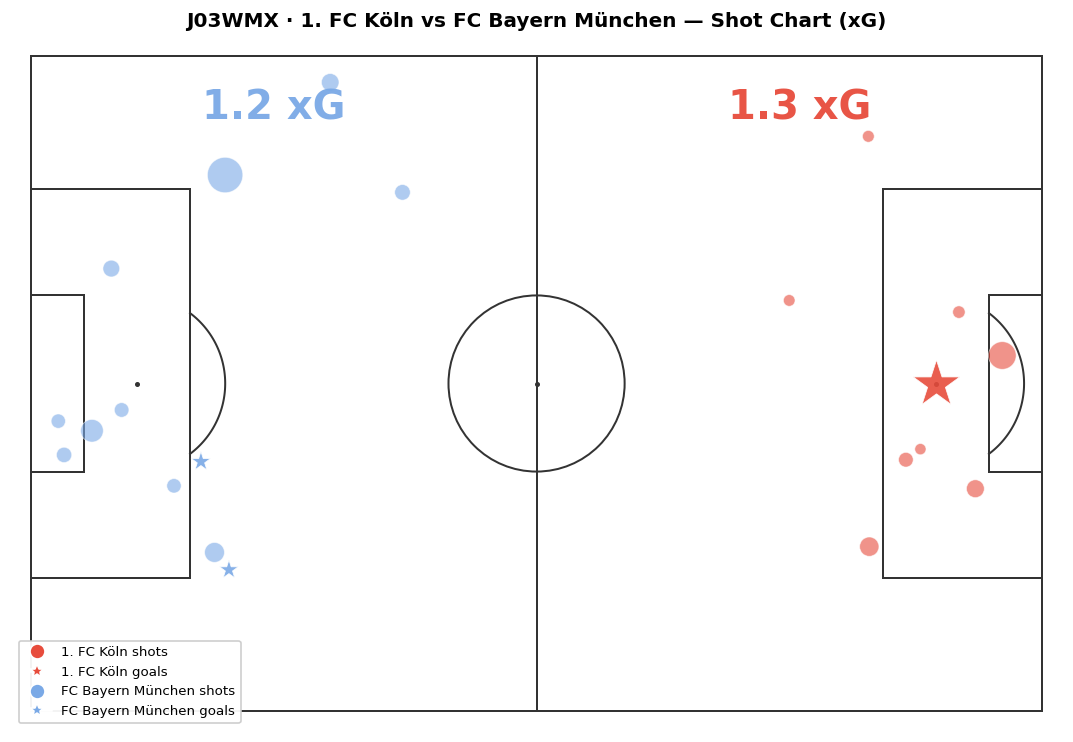

In [13]:
# Shot chart with xG markers
plot_shot_chart(events_J03WMX,
               title=f"J03WMX · {home_name} vs {away_name} — Shot Chart (xG)",
               team_names=tn_J03WMX)
plt.show()

### 2.3 · Tracking Heatmap

Positional density for a single player in **J03WMX**.
Tracking is downsampled to 1 Hz (`sample_rate=25`) for faster rendering.

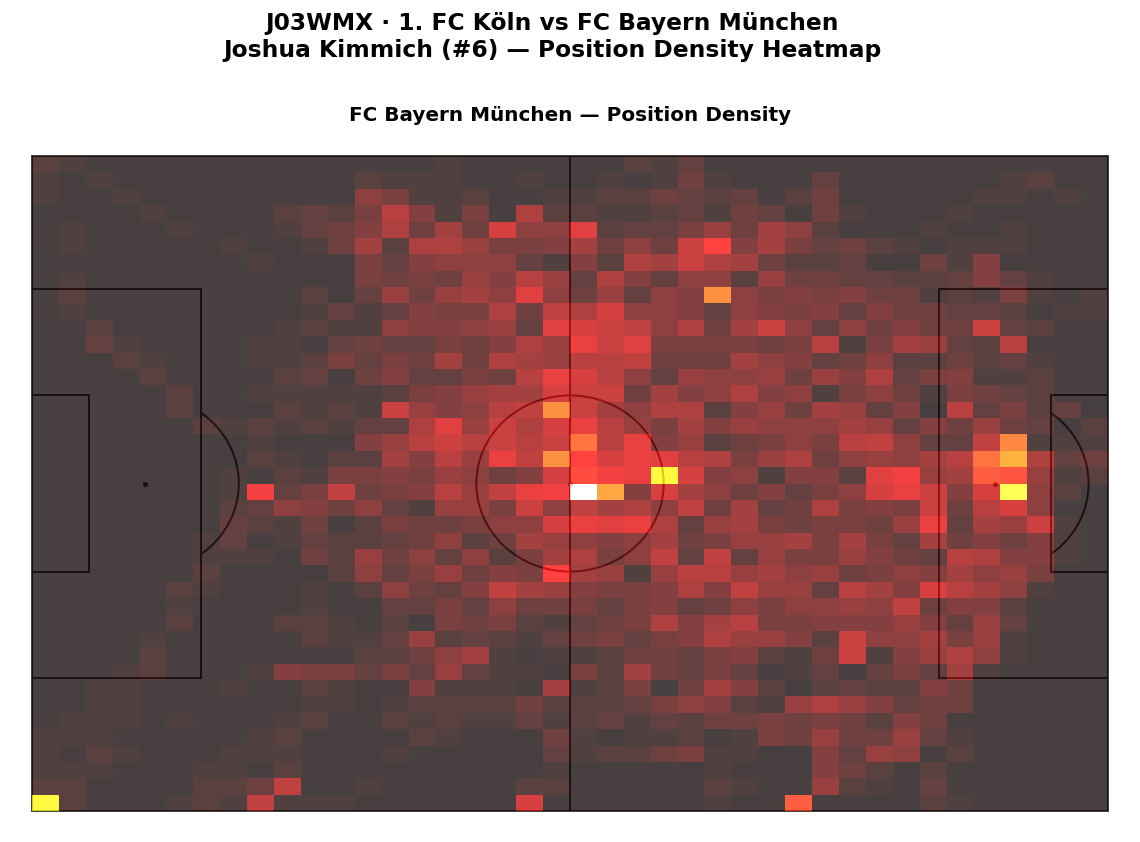

In [14]:
from src.parser import parse_tracking

# Load tracking data (downsampled to 1 Hz)
tracking_J03WMX = parse_tracking("J03WMX", DATA_DIR, sample_rate=25)

# Extract Joshua Kimmich (xID=8, Away) as a single-player heatmap example
kimmich_df = (
    tracking_J03WMX[tracking_J03WMX["team"] == "Away"]
    [["team", "segment", "gameclock_s", "p8_x", "p8_y"]]
    .rename(columns={"p8_x": "p0_x", "p8_y": "p0_y"})
    .copy()
)

fig, ax = plt.subplots(figsize=(12, 7.5))
fig.suptitle(
    f"J03WMX · {home_name} vs {away_name}\nJoshua Kimmich (#6) — Position Density Heatmap",
    fontsize=14, fontweight="bold", y=1.02,
)
plot_heatmap(kimmich_df, team="Away", ax=ax, team_names=tn_J03WMX)
plt.show()

### 2.4 · Possession Timeline

Per-minute possession momentum for **J03WMX**.
Bars above centre = Home dominance; below = Away dominance.

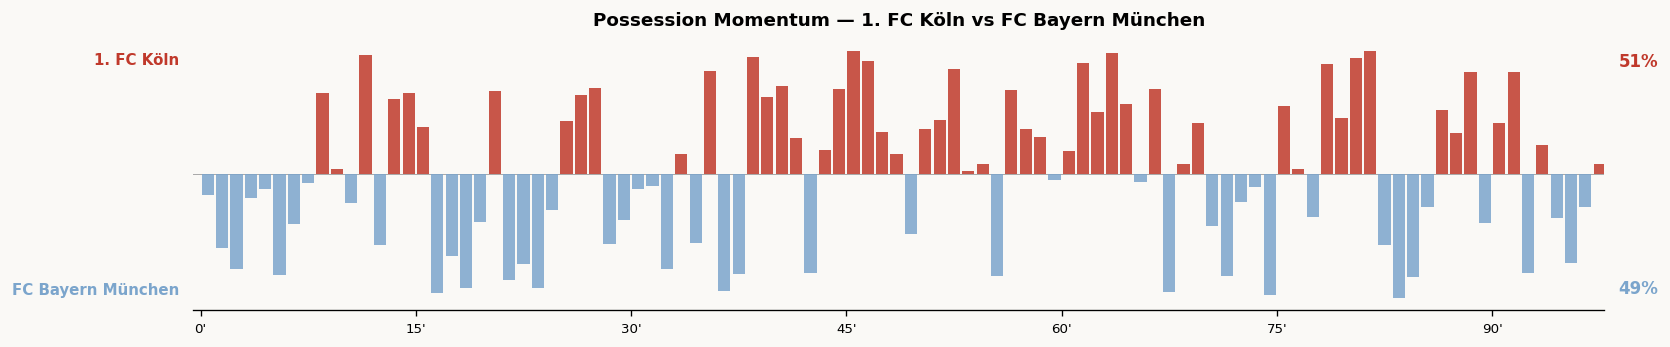

In [15]:
# Possession momentum chart (1-minute bins)
codes_J03WMX = codes_all[codes_all["match_id"] == "J03WMX"]
plot_possession_timeline(codes_J03WMX, bin_s=60, team_names=tn_J03WMX)
plt.tight_layout()
plt.show()

### 2.5 · Restart Analysis View

`plot_restart_map()` produces a **three-panel diagnostic**:
1. **Pitch map** — restart locations (marker shape/colour = restart type, bubble size = dead-ball duration).
2. **Dead-ball time share** — % of total dead-ball time per restart category.
3. **Stoppage counts** — number of stoppages by reason.

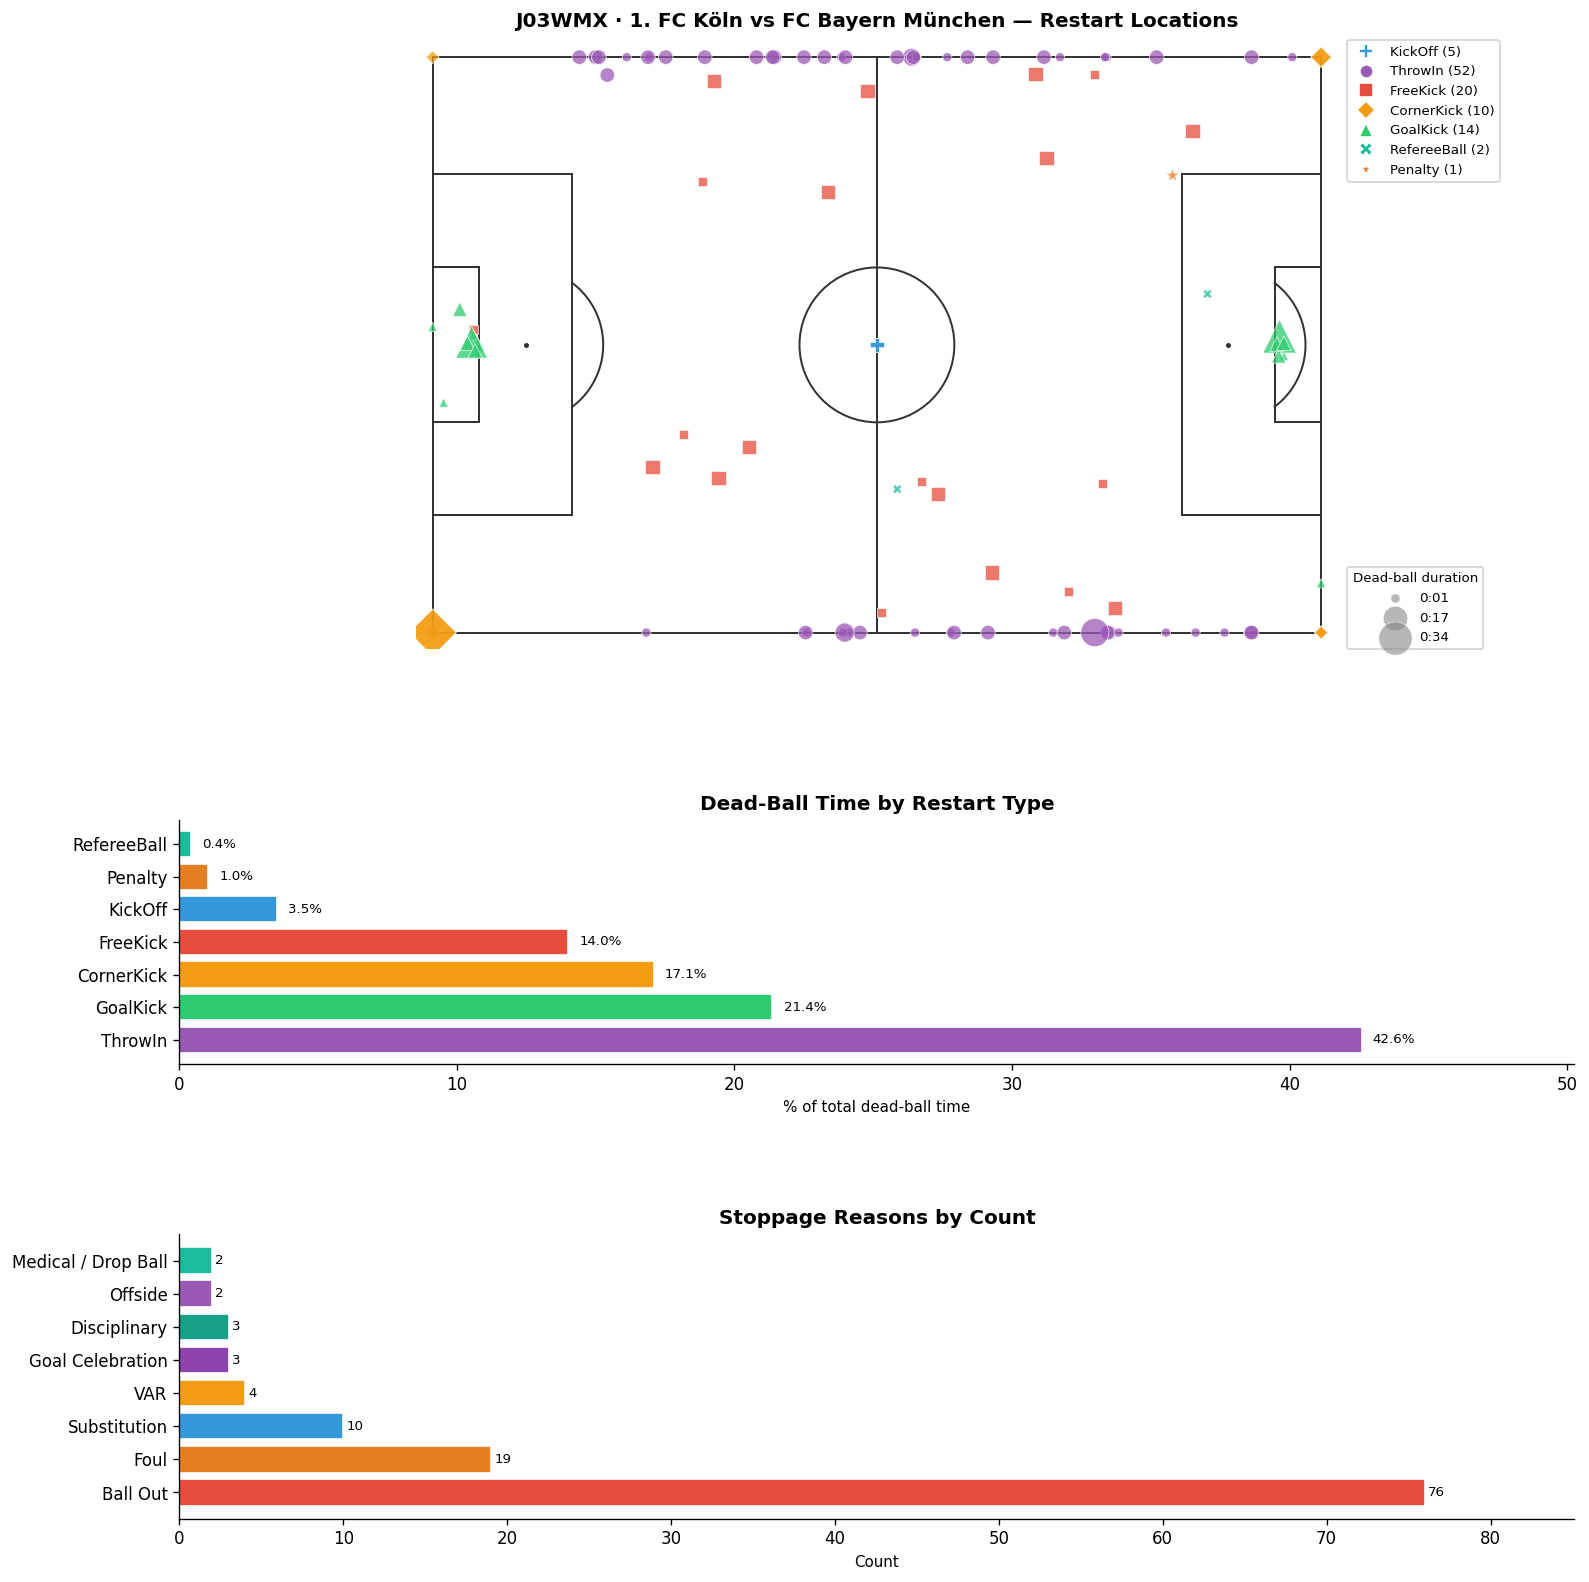

In [16]:
# Three-panel restart analysis
codes_J03WMX = codes_all[codes_all["match_id"] == "J03WMX"]
plot_restart_map(events_J03WMX, codes_df=codes_J03WMX,
                 title=f"J03WMX · {home_name} vs {away_name} — Restart Locations")
plt.show()

---
## Task 3 · Net Playing Time (NPT)

NPT is estimated with two methods and compared against official matchinfo values.

| Method | Definition |
|---|---|
| **M1** Frame-counting | `alive_frames × dt` where `ballstatus == 1` |
| **M2** Interval-summation | Sum of all contiguous alive intervals |
| **Official** | `PlayingTime*` fields from matchinformation XML |

Section 3.3 decomposes dead-ball episodes and applies a two-stage cause inference pipeline.

In [17]:
from src.parser import parse_all_ball_tracking
from src.npt_analysis import (
    compute_npt_frame, compute_npt_interval,
    load_official_npt, compare_npt_methods, npt_summary_all,
    build_episode_table, time_loss_by_restart, cause_by_restart,
    infer_cause, fmt_seconds_cols,
)

# Prepare single-match subsets for J03WMX
events_J03WMX = events_all[events_all["match_id"] == "J03WMX"]
codes_J03WMX  = codes_all[codes_all["match_id"]  == "J03WMX"]

### 3.1 · Single-Match Validation (`J03WMX`)

Per-segment breakdown of M1, M2, and their comparison against official values.

In [18]:
# Method 1: frame-counting
print("=== Method 1: Frame-counting ===")
display(fmt_seconds_cols(compute_npt_frame(codes_J03WMX)))

# Method 2: alive-interval summation
print("\n=== Method 2: Alive-interval summation ===")
display(fmt_seconds_cols(compute_npt_interval(codes_J03WMX)))

# Side-by-side comparison vs official
print("\n=== Method Comparison (Official / M1 / M2) ===")
display(fmt_seconds_cols(compare_npt_methods(codes_J03WMX, "J03WMX", DATA_DIR / "idsse_dataset")))

=== Method 1: Frame-counting ===


,match_id,segment,total_frames,alive_frames,dead_frames,total_s,npt_s,dead_s,npt_pct
0,J03WMX,firstHalf,70708.0,47225.0,23483.0,47:08,31:29,15:39,66.79
1,J03WMX,secondHalf,75259.0,38144.0,37115.0,50:10,25:26,24:45,50.68
2,J03WMX,total,145967.0,85369.0,60598.0,97:19,56:55,40:24,58.49



=== Method 2: Alive-interval summation ===


,match_id,segment,n_intervals,total_s,npt_s,dead_s,npt_pct,mean_interval_s,median_interval_s
0,J03WMX,firstHalf,41.0,47:08,31:29,15:39,66.79,0:46,0:25
1,J03WMX,secondHalf,62.0,50:10,25:26,24:45,50.68,0:25,0:16
2,J03WMX,total,103.0,97:19,56:55,40:24,58.49,1:11,0:41



=== Method Comparison (Official / M1 / M2) ===


,official_npt_s,official_npt_pct,m1_npt_s,m1_npt_pct,m1_err_s,m1_err_pct,m2_npt_s,m2_npt_pct,m2_err_s,m2_err_pct
segment,,,,,,,,,,
firstHalf,31:29,66.79,31:29,66.79,0:00,0.0,31:29,66.79,0:00,0.0
secondHalf,25:26,50.68,25:26,50.68,0:00,0.0,25:26,50.68,0:00,0.0


### 3.2 · Cross-Match Summary (All 7 Matches)

Aggregate comparison of **official vs computed NPT** across all available matches.

In [19]:
# All 7 matches: Official / M1 / M2 combined comparison
fmt_seconds_cols(npt_summary_all(codes_all, DATA_DIR / "idsse_dataset"))

,official_npt_s,m1_npt_s,m2_npt_s,m1_err_s,m2_err_s,official_npt_pct,m1_npt_pct,m2_npt_pct
match_id,,,,,,,,
J03WMX,56:55,56:55,56:55,0:00,0:00,58.5,58.5,58.5
J03WN1,45:35,45:35,45:35,0:00,0:00,48.3,48.3,48.3
J03WOH,47:58,47:58,47:58,0:00,0:00,52.4,52.4,52.4
J03WOY,50:51,50:51,50:51,0:00,0:00,53.5,53.5,53.5
J03WPY,54:18,54:18,54:18,0:00,0:00,55.7,55.7,55.7
J03WQQ,56:14,56:14,56:14,0:00,0:00,59.3,59.3,59.3
J03WR9,56:53,56:53,56:53,0:00,0:00,58.1,58.1,58.1


---
### 3.3 · Dead-Ball Episode Decomposition

Each dead interval is linked to a **probable cause** event near dead-ball start and a **restart** event near play resumption. Two inference passes then reduce `Unknown` labels:

1. **Restart-based mapping** — known restart types → likely causes.
2. **Ball-coordinate inference** — final ball position before stoppage resolves remaining unknowns.

**Why do `Unknown` labels appear?**

| Reason | Detail |
|---|---|
| **Ball-out-of-play without event** | The ball crosses a boundary line and `ballstatus` → 0, but no "BallOut" event is logged — only the restart (ThrowIn, GoalKick, etc.) appears. |
| **Event timing mismatch** | Some cause events are logged several seconds *after* the ball went dead, exceeding the look-back tolerance (`cause_tol = 5 s`). |
| **Half-time / full-time whistle** | The final dead interval of each half has no restart → both cause and restart remain Unknown. |
| **Delayed or missing annotations** | In rare cases the XML contains no matching event within the tolerance window. |

> The two-stage inference pipeline (Section 3.3.1) resolves the majority of Unknown labels by leveraging restart type mapping and ball coordinates.

In [20]:
# Build dead-ball episode table for all 7 matches (raw labels)
episodes = build_episode_table(codes_all, events_all)

print(f"Total episodes : {len(episodes)}  across {episodes['match_id'].nunique()} matches")
print(f"Unknown cause  : {(episodes['cause_label'] == 'Unknown').sum():3d} / {len(episodes)}")
print(f"Unknown restart: {(episodes['restart_label'] == 'Unknown').sum():3d} / {len(episodes)}")
fmt_seconds_cols(episodes.head(10))

Total episodes : 713  across 7 matches
Unknown cause  : 606 / 713
Unknown restart: 408 / 713


,match_id,segment,episode,dead_start_s,dead_end_s,duration_s,cause_eID,cause_label,cause_gameclock,restart_eID,restart_label,restart_gameclock
0,J03WMX,firstHalf,1,0:05,0:17,0:11,None,Unknown,NaN,ThrowIn_Play_Pass,ThrowIn,21.55
1,J03WMX,firstHalf,2,1:42,1:55,0:13,None,Unknown,NaN,GoalKick_Play_Pass,GoalKick,115.84
2,J03WMX,firstHalf,3,2:31,2:39,0:08,Foul,Foul,150.86,FreeKick_Play_Pass,FreeKick,159.74
3,J03WMX,firstHalf,4,3:56,4:09,0:14,None,Unknown,NaN,None,Unknown,NaN
4,J03WMX,firstHalf,5,4:23,4:32,0:09,None,Unknown,NaN,ThrowIn_Play_Pass,ThrowIn,272.08
5,J03WMX,firstHalf,6,4:39,4:50,0:11,None,Unknown,NaN,ThrowIn_Play_Pass,ThrowIn,290.41
6,J03WMX,firstHalf,7,4:52,5:02,0:09,None,Unknown,NaN,ThrowIn_Play_Pass,ThrowIn,301.88
7,J03WMX,firstHalf,8,7:49,8:41,0:51,ShotAtGoal_SuccessfulShot,Goal,469.77,KickOff_Play_Pass,KickOff,520.11
8,J03WMX,firstHalf,9,9:00,9:14,0:14,None,Unknown,NaN,GoalKick_Play_Pass,GoalKick,554.31
9,J03WMX,firstHalf,10,12:00,12:08,0:08,None,Unknown,NaN,ThrowIn_Play_Cross,ThrowIn,728.45


#### 3.3.1 · Cause Inference (All 7 Matches)

**Stage 1** (`infer_cause_from_restart`): Maps known restart types to likely causes (e.g., ThrowIn → BallOut_Sideline).

**Stage 2** (`infer_cause_from_ball`): For rows still Unknown, checks final ball position before stoppage — outside goal-line → goal-line out, outside touchline → sideline out, inside pitch → remains Unknown.

In [21]:
# Parse ball-tracking data for cause inference
print(f"Parsing ball-tracking data for {len(match_ids_to_parse)} matches ...")
ball_dfs = parse_all_ball_tracking(match_ids_to_parse, DATA_DIR / "idsse_dataset")

# Run two-stage cause inference
episodes_inferred, stats = infer_cause(episodes, ball_dfs)

print(f"\nStage 1 (restart-based)  : {stats['n_s1']:3d} episodes resolved")
print(f"  Unknown remaining      : {stats['n_after_s1']} / {stats['total']}")
print(f"Stage 2 (ball-coordinate): {stats['n_s2']:3d} episodes resolved")
print(f"  Unknown remaining      : {stats['n_final']} / {stats['total']} "
      f"({stats['n_final'] / stats['total'] * 100:.1f}%)")
print(f"Total resolved           : {stats['n_s1'] + stats['n_s2']} / {stats['total']} "
      f"({(stats['n_s1'] + stats['n_s2']) / stats['total'] * 100:.1f}%)")

Parsing ball-tracking data for 7 matches ...
  J03WMX ... 145,967 frames
  J03WN1 ... 145,967 frames
  J03WN1 ... 141,561 frames
  J03WPY ... 141,561 frames
  J03WPY ... 146,211 frames
  J03WOH ... 146,211 frames
  J03WOH ... 137,214 frames
  J03WQQ ... 137,214 frames
  J03WQQ ... 142,345 frames
  J03WOY ... 142,345 frames
  J03WOY ... 142,536 frames
  J03WR9 ... 142,536 frames
  J03WR9 ... 146,810 frames
146,810 frames

Stage 1 (restart-based)  : 216 episodes resolved
  Unknown remaining      : 390 / 713
Stage 2 (ball-coordinate): 242 episodes resolved
  Unknown remaining      : 148 / 713 (20.8%)
Total resolved           : 458 / 713 (64.2%)

Stage 1 (restart-based)  : 216 episodes resolved
  Unknown remaining      : 390 / 713
Stage 2 (ball-coordinate): 242 episodes resolved
  Unknown remaining      : 148 / 713 (20.8%)
Total resolved           : 458 / 713 (64.2%)


> **Limitations:** Unknown episodes can remain after both stages when event timing is delayed, restart tags are missing/late, or ball position alone is insufficient to infer causality.

#### 3.3.2 · Time-Loss by Restart Type

Aggregated dead-ball duration broken down by **restart type**, both per match and across all 7 matches.

In [22]:
# Time-loss breakdown by restart type
tl_restart = time_loss_by_restart(episodes_inferred)

# Aggregate summary across all matches
print("=== Time-loss by restart — ALL matches ===")
display(
    fmt_seconds_cols(
        tl_restart[tl_restart["match_id"] == "ALL"].set_index("restart_label")
    )
)

# Per-match pivot with mm:ss formatting
print("\n=== Time-loss by restart — per match (total_s) pivot ===")
pivot = (
    tl_restart[tl_restart["match_id"] != "ALL"]
    .pivot(index="restart_label", columns="match_id", values="total_s")
    .fillna(0)
    .assign(MEAN=lambda d: d.mean(axis=1).round(1))
    .sort_values("MEAN", ascending=False)
)
display(pivot.map(lambda v: f"{int(v // 60)}:{int(v % 60):02d}" if v > 0 else "—"))

=== Time-loss by restart — ALL matches ===


,match_id,n_episodes,total_s,mean_s,median_s,pct_of_total
restart_label,,,,,,
Unknown,ALL,408,182:43,0:27,0:21,61.0
FreeKick,ALL,85,44:52,0:32,0:29,15.0
ThrowIn,ALL,136,33:37,0:15,0:12,11.2
GoalKick,ALL,58,23:51,0:25,0:24,8.0
CornerKick,ALL,20,11:40,0:35,0:34,3.9
Penalty,ALL,1,1:28,1:28,1:28,0.5
KickOff,ALL,3,0:51,0:17,0:00,0.3
RefereeBall,ALL,2,0:39,0:19,0:19,0.2



=== Time-loss by restart — per match (total_s) pivot ===


match_id,J03WMX,J03WN1,J03WOH,J03WOY,J03WPY,J03WQQ,J03WR9,MEAN
restart_label,,,,,,,,
Unknown,26:22,28:23,24:34,32:48,11:27,22:15,36:49,26:06
FreeKick,3:17,7:22,7:25,5:48,10:36,10:02,0:18,6:24
ThrowIn,6:05,8:31,4:06,4:06,7:24,1:42,1:40,4:48
GoalKick,2:04,3:47,5:05,1:05,7:19,4:03,0:25,3:24
CornerKick,1:42,0:42,2:18,—,6:21,0:35,—,1:40
Penalty,—,—,—,—,—,—,1:28,0:12
KickOff,0:51,0:00,—,0:00,—,—,—,0:07
RefereeBall,—,—,—,0:21,—,—,0:17,0:05


#### 3.3.3 · Cause × Restart Pivot (After Inference)

Two pivot views: **episode count** and **total dead-ball time** by cause × restart.

In [23]:
from src.npt_analysis import fmt_mmss

# Cause × Restart pivot — episode count
print("=== Cause × Restart  [count] ===")
display(cause_by_restart(episodes_inferred, metric="count"))

# Cause × Restart pivot — total dead-ball duration
print("\n=== Cause × Restart  [total dead-ball time, mm:ss] ===")
dur_pivot = cause_by_restart(episodes_inferred, metric="duration_s")
display(dur_pivot.map(lambda v: fmt_mmss(v) if v > 0 else "—"))

=== Cause × Restart  [count] ===


restart_label,CornerKick,FreeKick,GoalKick,KickOff,Penalty,RefereeBall,ThrowIn,Unknown,TOTAL
cause_label,,,,,,,,,
TOTAL,20,85,58,3,1,2,136,408,713
BallOut_Sideline,0,0,0,0,0,0,136,153,289
Unknown,0,28,0,0,0,2,0,118,148
BallOut_GoalLine,0,0,58,0,0,0,0,89,147
Foul,0,52,0,0,1,0,0,32,85
BallOut_GoalLine_Corner,20,0,0,0,0,0,0,0,20
Goal,0,0,0,1,0,0,0,11,12
Offside,0,4,0,0,0,0,0,2,6
Substitution,0,1,0,0,0,0,0,1,2



=== Cause × Restart  [total dead-ball time, mm:ss] ===


restart_label,CornerKick,FreeKick,GoalKick,KickOff,Penalty,RefereeBall,ThrowIn,Unknown,TOTAL
cause_label,,,,,,,,,
TOTAL,11:40,44:52,23:51,0:52,1:28,0:39,33:38,182:43,299:41
BallOut_Sideline,—,—,—,—,—,—,33:38,41:28,75:05
BallOut_GoalLine,—,—,23:51,—,—,—,—,47:55,71:46
Unknown,—,12:51,—,—,—,0:39,—,57:16,70:46
Foul,—,30:10,—,—,1:28,—,—,19:20,50:58
Goal,—,—,—,0:51,—,—,—,13:05,13:56
BallOut_GoalLine_Corner,11:40,—,—,—,—,—,—,—,11:40
Offside,—,1:34,—,—,—,—,—,0:23,1:57
Disciplinary,—,—,—,—,—,—,—,1:31,1:31
